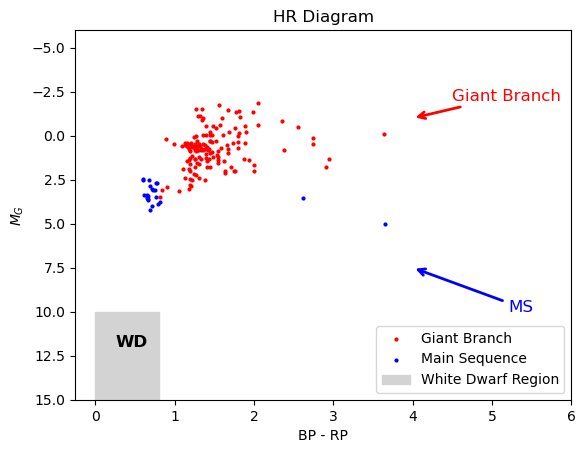

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

# Open the FITS file
hdul = fits.open('APOGEE_stars.fits')
data = hdul[1].data  # Often, the first extension contains the table
colnames = hdul[1].columns.names # List of the column names

# Create a mask with the given criteria that can be used to mask the bad data.

mask = (
    (data['STARFLAG'] == 0) &
    (data['ASPCAPFLAG'] == 0) &
    (data['SNR'] > 10) &
    (data['GAIAEDR3_PARALLAX'] / data['GAIAEDR3_PARALLAX_ERROR'] > 5) &
    (~np.isnan(data['GAIAEDR3_PHOT_G_MEAN_MAG'])) &
    (~np.isnan(data['GAIAEDR3_PHOT_BP_MEAN_MAG'])) &
    (~np.isnan(data['GAIAEDR3_PHOT_RP_MEAN_MAG']))
)

good_data = data[mask]  # Application of the mask to filter out the good data.

N = len(good_data)  # Length of good_data is how much stars we have in total.
random_ind = np.random.choice(N, int(0.001*N), replace=False)  # Randomly select 80% of the indices.
random_data = good_data[random_ind]  # Get the data from the good_data list by the indices.

# Define all needed data for further calculations from the random data.

parallax = random_data['GAIAEDR3_PARALLAX'] # Gaia parallax in milliarcseconds
m_G = random_data['GAIAEDR3_PHOT_G_MEAN_MAG'] # Apparent G-band magnitude
BP = random_data['GAIAEDR3_PHOT_BP_MEAN_MAG'] # BP magnitude
RP = random_data['GAIAEDR3_PHOT_RP_MEAN_MAG'] # RP magnitude

# Calculate colour, distance and absolute magnitude.

colour = BP - RP  # Calculate colour index BP-RP.
distance = 1000/parallax  # Convert parallax to distance in parsec.
abs_mag_G = m_G - 5*np.log10(distance)+5  # Absolute G-band magnitude

# Separate the Main Sequence from the Giant branch and the White Dwarfs using masks.

giants_mask = ((abs_mag_G < 3.5) & (colour > 0.8))
wd_mask = ((abs_mag_G > 10) & (colour <= 0.8))
MS_mask = ~(giants_mask | wd_mask)  # Everything that does not fit the Giants or White Dwarfs criteria belongs on the Main Sequence.

# Plot the HR-diagram, with color(BP-RP) on the x-axis and absolute magnitude on the y-axis.

plt.scatter(colour[giants_mask], abs_mag_G[giants_mask], s=4, color='red', label='Giant Branch')  # Plot the Giant Branch.
plt.scatter(colour[MS_mask], abs_mag_G[MS_mask], s=4, color='blue', label='Main Sequence')  # Plot the Main Sequence.

# Plot the White Dwarf region

plt.fill_betweenx([10, 20], 0, 0.8, color='lightgrey', label = 'White Dwarf Region') # Grey rectangle for WD region.
plt.text(0.25, 12, 'WD', fontsize=12, fontweight='bold')    # Label the box.

# Add arrows and text that point to the Giant Branch and the Main Sequence.

plt.annotate('Giant Branch', xy=(4, -1), xytext=(4.5, -2),
             color='red', fontsize=12,
             arrowprops=dict(arrowstyle='->', color='red', lw=2))

plt.annotate('MS', xy=(4, 7.5), xytext=(5.2,10),
             color='blue', fontsize=12,
             arrowprops=dict(arrowstyle='->', color='blue', lw=2))

# Set axis limits and invert the y-axis.

plt.xlim(-0.25,6)
plt.ylim(-6, 15)
plt.gca().invert_yaxis() # Invert y-axis so that brighter stars appear higher on the diagram.

# Create axis labels and the title.

plt.xlabel('BP - RP')
plt.ylabel(r'$M_G$')
plt.title('HR Diagram')

plt.legend(loc='lower right')
plt.show()